# Exploratory Data Analysis — MAGFiLO 1.0 (Kaggle 2026)

Solar dark filaments in GONG H-alpha full-disk images, annotated by up to three
people per image. This notebook establishes the facts that the segmentation
pipeline has to be built around.

Submissions are scored with Panoptic Quality at an IoU threshold of 0.5:

    PQ = sum(IoU over matched pairs) / (|TP| + 0.5|FP| + 0.5|FN|)

Only pairs above IoU 0.5 count, and the metric is evaluated once per
*annotator-image*, not once per image. Four questions follow from that, and
this notebook answers each with a number:

1. How large is a filament? Small objects lose IoU to a few pixels of error.
2. How many are there per image? That fixes the scale of the detection problem.
3. Do the six GONG stations look different? If so, the model has to generalize
   across them and the validation folds have to be stratified by station.
4. How much do annotators disagree? Their disagreement is an upper bound on
   any achievable score.

In [1]:
from __future__ import annotations

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from filament.data.coco import load_annotations, observatory_code
from filament.paths import load_paths

paths = load_paths().require_dataset()
dataset = load_annotations(paths.train_annotations)

# Colors and mark weights are kept in one place so every figure below reads as
# one system. Slots 1-3 of a categorical palette validated for colour-vision
# deficiency; a single-series figure uses slot 1 alone.
SERIES = ("#2a78d6", "#eb6834", "#1baf7a")
INK = "#0b0b0b"
INK_MUTED = "#52514e"
SURFACE = "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": INK_MUTED,
        "axes.labelcolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "semibold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "text.color": INK,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "grid.color": "#e3e2dd",
        "grid.linewidth": 0.8,
        "font.size": 10,
        "figure.dpi": 110,
    }
)

print(f"{len(dataset.annotator_images)} annotator-images")
print(f"{len(dataset.stems)} unique images")
print(f"{len(dataset.annotations)} annotated filaments")

1154 annotator-images
707 unique images
8199 annotated filaments


## 1. Who annotated what

`image_id` is `<annotator batch>-<image stem>`, so the same image appears once
per annotator. Roughly two images in five were annotated by more than one
person, and those images are scored more than once.

In [2]:
per_image = Counter(len(entries) for entries in dataset.by_stem().values())
for annotators in sorted(per_image):
    share = 100 * per_image[annotators] / len(dataset.stems)
    print(f"{annotators} annotator(s): {per_image[annotators]:4d} images ({share:4.1f}%)")

stations = Counter(observatory_code(stem) for stem in dataset.stems)
print()
print(
    "Images per GONG station:",
    "  ".join(f"{code}={count}" for code, count in sorted(stations.items())),
)

1 annotator(s):  411 images (58.1%)
2 annotator(s):  145 images (20.5%)
3 annotator(s):  151 images (21.4%)

Images per GONG station: Bh=118  Ch=125  Lh=127  Mh=125  Th=110  Uh=102


## 2. Filament area

A filament covers about 1,200 pixels out of 4.2 million: a thin, elongated
object. The consequence for the metric is direct — on a 1,200-pixel object,
mislabelling a 400-pixel sliver already drops IoU below 0.5, which turns one
prediction into a false positive *and* a false negative.

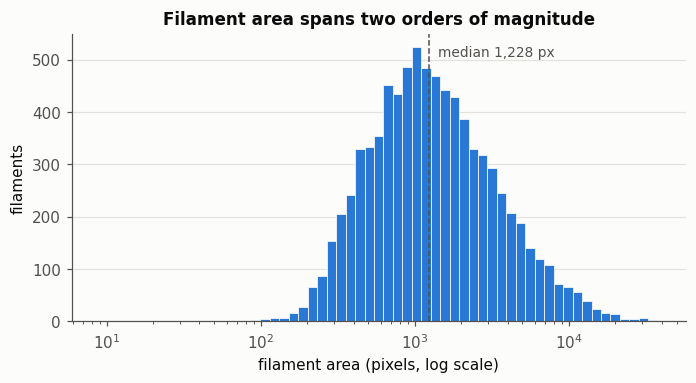

min          9 px
p10        410 px
p25        670 px
p50      1,228 px
p75      2,438 px
p90      4,685 px
p100    37,739 px


In [3]:
areas = np.array([annotation.area for annotation in dataset.annotations])

fig, ax = plt.subplots(figsize=(7.2, 3.4))
ax.hist(
    areas,
    bins=np.logspace(np.log10(areas.min()), np.log10(areas.max()), 60),
    color=SERIES[0],
    edgecolor=SURFACE,
    linewidth=0.5,
)
ax.set_xscale("log")
ax.set_xlabel("filament area (pixels, log scale)")
ax.set_ylabel("filaments")
ax.set_title("Filament area spans two orders of magnitude")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)

median = float(np.median(areas))
ax.axvline(median, color=INK_MUTED, linewidth=1.0, linestyle="--")
ax.annotate(
    f"median {median:,.0f} px",
    xy=(median, ax.get_ylim()[1] * 0.92),
    xytext=(6, 0),
    textcoords="offset points",
    color=INK_MUTED,
    fontsize=9,
)
plt.show()

print(f"min  {areas.min():9,.0f} px")
for percentile in (10, 25, 50, 75, 90, 100):
    print(f"p{percentile:<3d} {np.percentile(areas, percentile):9,.0f} px")

## 3. Filaments per annotator-image

Seven filaments in a typical image, up to 26 in an active one, and never zero.
A predictor that returns nothing is therefore never right, but it is also not
as wrong as it could be: an unmatched prediction costs twice what a miss costs.

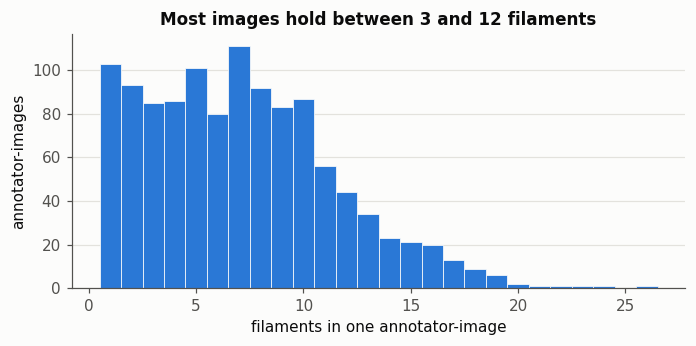

median 7   mean 7.1   min 1   max 26


In [4]:
counts = np.array([len(entry) for entry in dataset.annotator_images])

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.hist(
    counts,
    bins=np.arange(0.5, counts.max() + 1.5),
    color=SERIES[0],
    edgecolor=SURFACE,
    linewidth=0.5,
)
ax.set_xlabel("filaments in one annotator-image")
ax.set_ylabel("annotator-images")
ax.set_title("Most images hold between 3 and 12 filaments")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

print(
    f"median {np.median(counts):.0f}   mean {counts.mean():.1f}   "
    f"min {counts.min()}   max {counts.max()}"
)

## 4. The six GONG stations

GONG observes from six sites. Brightness and contrast are measured over the
solar disk only, since the black sky around it would otherwise dominate both
statistics, and on a sample of 30 images per station.

Brightness and contrast are plotted separately rather than on two y-axes: they
are different quantities, and overlaying them on one pair of axes would invite
a comparison that means nothing.

In [5]:
RNG = np.random.default_rng(0)
SAMPLE_PER_STATION = 30
DISK_THRESHOLD = 20  # pixel value separating the disk from the empty sky

by_station: dict[str, list[str]] = {}
for stem in dataset.stems:
    by_station.setdefault(observatory_code(stem), []).append(stem)

statistics: dict[str, tuple[np.ndarray, np.ndarray]] = {}
for station, stems in sorted(by_station.items()):
    chosen = RNG.choice(stems, size=min(SAMPLE_PER_STATION, len(stems)), replace=False)
    brightness, contrast = [], []
    for stem in chosen:
        pixels = np.asarray(Image.open(paths.train_images / f"{stem}.jpeg").convert("L"))
        disk = pixels[pixels > DISK_THRESHOLD]
        brightness.append(disk.mean())
        contrast.append(disk.std())
    statistics[station] = (np.array(brightness), np.array(contrast))

print(f"{SAMPLE_PER_STATION} images sampled per station, {len(statistics)} stations")

30 images sampled per station, 6 stations


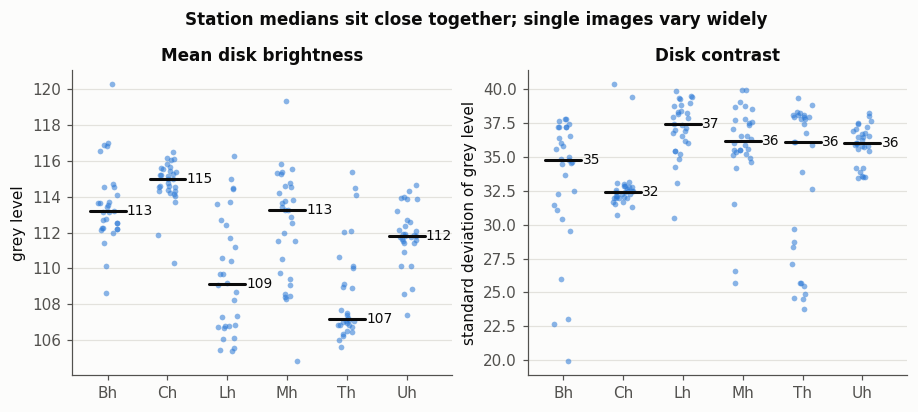

Bh  brightness  113.2 (range 108.6-120.3)   contrast  34.8 (range 19.9-37.8)
Ch  brightness  115.0 (range 110.3-116.5)   contrast  32.4 (range 30.7-40.3)
Lh  brightness  109.1 (range 105.4-116.3)   contrast  37.4 (range 30.5-39.8)
Mh  brightness  113.3 (range 104.8-119.3)   contrast  36.1 (range 25.7-39.9)
Th  brightness  107.2 (range 105.6-115.4)   contrast  36.1 (range 23.8-39.3)
Uh  brightness  111.8 (range 107.4-114.6)   contrast  36.0 (range 33.4-38.2)


In [6]:
labels = list(statistics)
positions = np.arange(len(labels))
JITTER = np.random.default_rng(1)

# One dot per sampled image plus a median rule, rather than bars: the spread
# within a station is the point, and a bar chart anchored at zero would show
# six bars of the same height.
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.6))
for ax, index, title, unit in (
    (axes[0], 0, "Mean disk brightness", "grey level"),
    (axes[1], 1, "Disk contrast", "standard deviation of grey level"),
):
    for position, station in zip(positions, labels, strict=True):
        values = statistics[station][index]
        offsets = JITTER.uniform(-0.17, 0.17, size=len(values))
        ax.scatter(
            position + offsets, values, s=14, color=SERIES[0], alpha=0.55, linewidths=0, zorder=2
        )
        median = float(np.median(values))
        ax.plot(
            [position - 0.3, position + 0.3],
            [median, median],
            color=INK,
            linewidth=2.0,
            solid_capstyle="round",
            zorder=3,
        )
        ax.annotate(
            f"{median:.0f}", xy=(position + 0.32, median), fontsize=9, color=INK, va="center"
        )
    ax.set_xticks(positions, labels)
    ax.set_xlim(-0.6, len(labels) - 0.25)
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.grid(axis="y", linewidth=0.8)
    ax.set_axisbelow(True)
fig.suptitle(
    "Station medians sit close together; single images vary widely",
    y=1.03,
    fontsize=11,
    fontweight="semibold",
)
plt.show()

for station in labels:
    brightness, contrast = statistics[station]
    print(
        f"{station}  brightness {np.median(brightness):6.1f} "
        f"(range {brightness.min():5.1f}-{brightness.max():5.1f})   "
        f"contrast {np.median(contrast):5.1f} "
        f"(range {contrast.min():4.1f}-{contrast.max():4.1f})"
    )

## 5. How much annotators disagree

For images with more than one annotator, the gap between the largest and the
smallest number of filaments drawn is the cheapest available measure of
disagreement. It averages around 2.5 filaments — on a median count of 7.

This is a ceiling, not noise to be cleaned away. A filament only one of three
annotators drew is a true positive against that annotator and a false positive
against the other two, so predicting it is worth it only when it is nearly
certain. The same arithmetic makes filaments that everyone drew worth three
times as much.

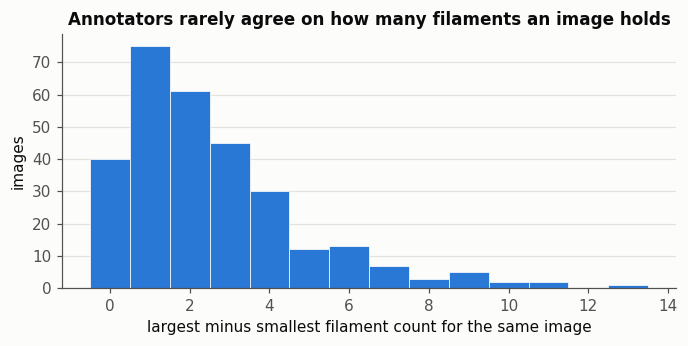

296 multi-annotator images
mean gap 2.58   median 2   max 13
identical counts: 13.5% of them


In [7]:
gaps = []
for stems_entries in dataset.by_stem().values():
    if len(stems_entries) < 2:
        continue
    drawn = [len(entry) for entry in stems_entries]
    gaps.append(max(drawn) - min(drawn))
gaps = np.array(gaps)

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.hist(
    gaps, bins=np.arange(-0.5, gaps.max() + 1.5), color=SERIES[0], edgecolor=SURFACE, linewidth=0.5
)
ax.set_xlabel("largest minus smallest filament count for the same image")
ax.set_ylabel("images")
ax.set_title("Annotators rarely agree on how many filaments an image holds")
ax.grid(axis="y", linewidth=0.8)
ax.set_axisbelow(True)
plt.show()

print(f"{len(gaps)} multi-annotator images")
print(f"mean gap {gaps.mean():.2f}   median {np.median(gaps):.0f}   max {gaps.max()}")
print(f"identical counts: {100 * (gaps == 0).mean():.1f}% of them")

## 6. One image, three annotators

The disagreement above is a number; this is what it looks like. The left panel
is the full disk with every annotator's outlines drawn over it, the right panel
zooms on one filament where their outlines differ.

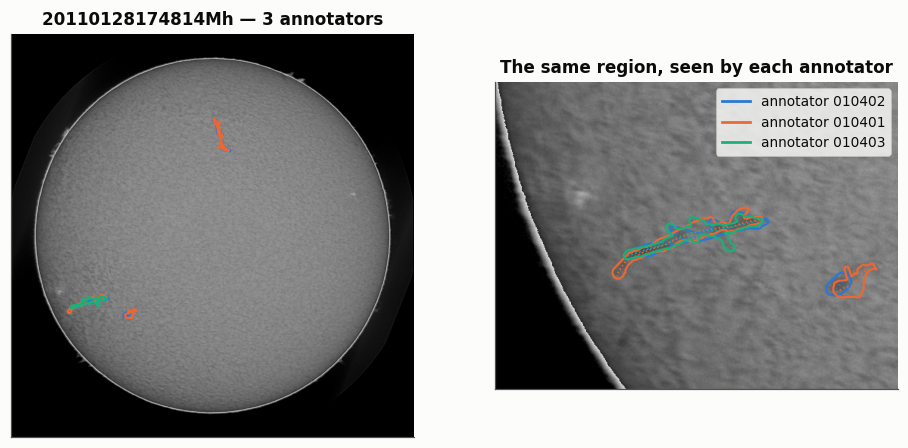

annotator 010402: 3 filaments, areas [670, 2026, 2950]
annotator 010401: 3 filaments, areas [1269, 1862, 3263]
annotator 010403: 1 filaments, areas [3139]


In [8]:
three = [stem for stem, entries in dataset.by_stem().items() if len(entries) == 3]
stem = sorted(three)[0]
entries = dataset.by_stem()[stem]
pixels = np.asarray(Image.open(paths.train_images / f"{stem}.jpeg").convert("L"))


def outline(axis, annotation, color):
    polygon = np.asarray(annotation.segmentation[0]).reshape(-1, 2)
    axis.plot(*np.vstack([polygon, polygon[:1]]).T, color=color, linewidth=1.4)


fig, axes = plt.subplots(1, 2, figsize=(10.4, 5.2))
for axis in axes:
    axis.imshow(pixels, cmap="gray", vmin=0, vmax=255)
    axis.set_xticks([])
    axis.set_yticks([])

for entry, color in zip(entries, SERIES, strict=True):
    for annotation in entry.annotations:
        outline(axes[0], annotation, color)
axes[0].set_title(f"{stem} — {len(entries)} annotators")

# Zoom on the filament the first annotator drew largest, which is the one most
# likely to have been seen by everyone.
target = max(entries[0].annotations, key=lambda annotation: annotation.area)
x, y, width, height = target.bbox
pad = 0.9 * max(width, height)
axes[1].set_xlim(x - pad, x + width + pad)
axes[1].set_ylim(y + height + pad, y - pad)
axes[1].set_title("The same region, seen by each annotator")

handles = []
for entry, color in zip(entries, SERIES, strict=True):
    for annotation in entry.annotations:
        outline(axes[1], annotation, color)
        spine = np.asarray(annotation.spine).reshape(-1, 2)
        axes[1].plot(*spine.T, color=color, linewidth=1.0, linestyle=":")
    handles.append(
        plt.Line2D([], [], color=color, linewidth=1.8, label=f"annotator {entry.annotator}")
    )
axes[1].legend(
    handles=handles,
    loc="upper right",
    frameon=True,
    fontsize=9,
    facecolor=SURFACE,
    edgecolor="#e3e2dd",
)
plt.show()

for entry in entries:
    print(
        f"annotator {entry.annotator}: {len(entry)} filaments, "
        f"areas {sorted(int(a.area) for a in entry.annotations)}"
    )

## 7. What this means for the pipeline

- **Small, elongated objects.** A median filament is 1,228 px. Losing a
  400-pixel sliver already costs the IoU 0.5 gate, so mask quality near the
  boundary matters more than average Dice does.
- **Normalise per image, and stratify by station anyway.** Station medians
  sit within a few grey levels of each other, but single images range across
  tens of grey levels inside every station. Per-image contrast normalisation is
  therefore the lever that matters; stratifying the folds by station stays as
  cheap insurance against a fold drawing an unlucky mix.
- **Group by image.** Annotators of one image must not straddle a split, or
  validation scores an image the model trained on.
- **Weight by agreement.** A filament only one of three annotators drew pays
  once and costs twice. Predictions should be biased towards what annotators
  agreed on, and the confidence and minimum-area cut-offs should be tuned
  against PQ directly rather than against Dice.